**Una** de las principales pegas que se les pone a los modelos de ML es que son una **caja negra**,
como los basados en redes neuronales, que no sabes en que se basan para tomar la decision. Por ejemplo, en un clasificador de imagenes de perros y gatos, en las redes neuronales no sabes en qué se ha basado para tomar la decisión. ¿Habrá estado mirando las orejas y los bigotes del gato? ¿será otra cosa en la que se ha fijado?. Estos modelos funcionan, pero no sabemos en qué se han basado para tomar esa decisión.
Por ello, **el interpretar los modelos de ML es de una importancia capital**, para ello, se utilizan los valores SHAP.

Es muy interesante saber lo que esta pasando en los modelos de ML, de tal forma que nos ayude a entender por qué el modelo ha tomado una decision u otra, por ejemplo en un problema de clasificación.

Esta basado en la teoria del juego.

La explicacion explicación básica es: Los valores SHAP son una contribucion marginal de cada una de las features a un resultado.

El funcionamiento es que los valores de SHAP calculan esta contribucion marginal prediciendo la salida del modelo para ese valor, con y sin esa caracteristica. Es decir:
- Quitan la caracteristica, hacen la prediccion
- Ponen la caracteristica, y hacen la prediccion
- La diferencia entre las 2 predicciones es la contribucion parcial de esa prediccion a la prediccion final.

# **SHAP: Interpreting Machine Learning models**

Definition from the authors:

`SHAP (SHapley Additive exPlanations) is a game-theoretic approach to explain the output of any machine learning model. It connects optimal credit allocation with local explanations using the classic Shapley values from game theory and their related extensions. (source: https://github.com/slundberg/shap)`

Shapley values are a measure of the contribution of each predictor (feature) in a machine learning model. Given a feature set, which is each feature's marginal contribution to the overall prediction?. The marginal contribution would be how much each feature pushes the prediction to move away from the overall prediction. Shapley values compute this marginal contribution by computing the predicted value with and without the feature value currently under observation and take the difference. For the whole dataset, the final Shapley value is computed by averaging the marginal contribution of the feature across all subsets inside the feature set where the feature participates.

Shapley values are clearly explained in: https://santiagof.medium.com/model-interpretability-making-your-model-confess-shapley-values-5fb95a10a624.

For more info on `shap` library and how to use it check:

- https://towardsdatascience.com/shap-how-to-interpret-machine-learning-models-with-python-2323f5af4be9

- https://medium.com/analytics-vidhya/explainer-dashboard-build-interactive-dashboards-for-machine-learning-models-fda63e0eab9

- https://medium.com/analytics-vidhya/an-explanation-for-explainable-ai-xai-d56ae3dacd13

For a survey of methods for Interpretable ML, check the following book (free online version):

- https://christophm.github.io/interpretable-ml-book/index.html

and also:

- https://santiagof.medium.com/model-interpretability-making-your-model-confess-shapley-values-5fb95a10a624







# **Classification example:**

### **Load dataset**

In [ ]:
import pandas as pd

# download the winequality dataset
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"

df_wine = pd.read_csv(url, delimiter=";")

In [ ]:
df_wine.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


Separate features and target variables:

In [ ]:
X = df_wine.iloc[:,0:11]
X.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4


In [ ]:
y = df_wine.iloc[:,11]
y.head()

,quality
0,5
1,5
2,5
3,6
4,5


In [ ]:
y.value_counts()

,count
quality,
5,681
6,638
7,199
4,53
8,18
3,10


Thus, wine quality can take 6 different values, ranging from 3 (lowest quality) to 8 (highest quality)

## **Optional: EDA**

In [ ]:
import seaborn as sns

sns.pairplot(df_wine)

This plot highlight several interesting correlations (both direct and inverse) between some of the wine characteristics, that determine the quality. For example, there is an inverse correlation between PH and fixed acidity, as expected, and a direct correlation between density and fixed acidity.  

Let's plot the correlations to confirm our hypotesis:

<Axes: >

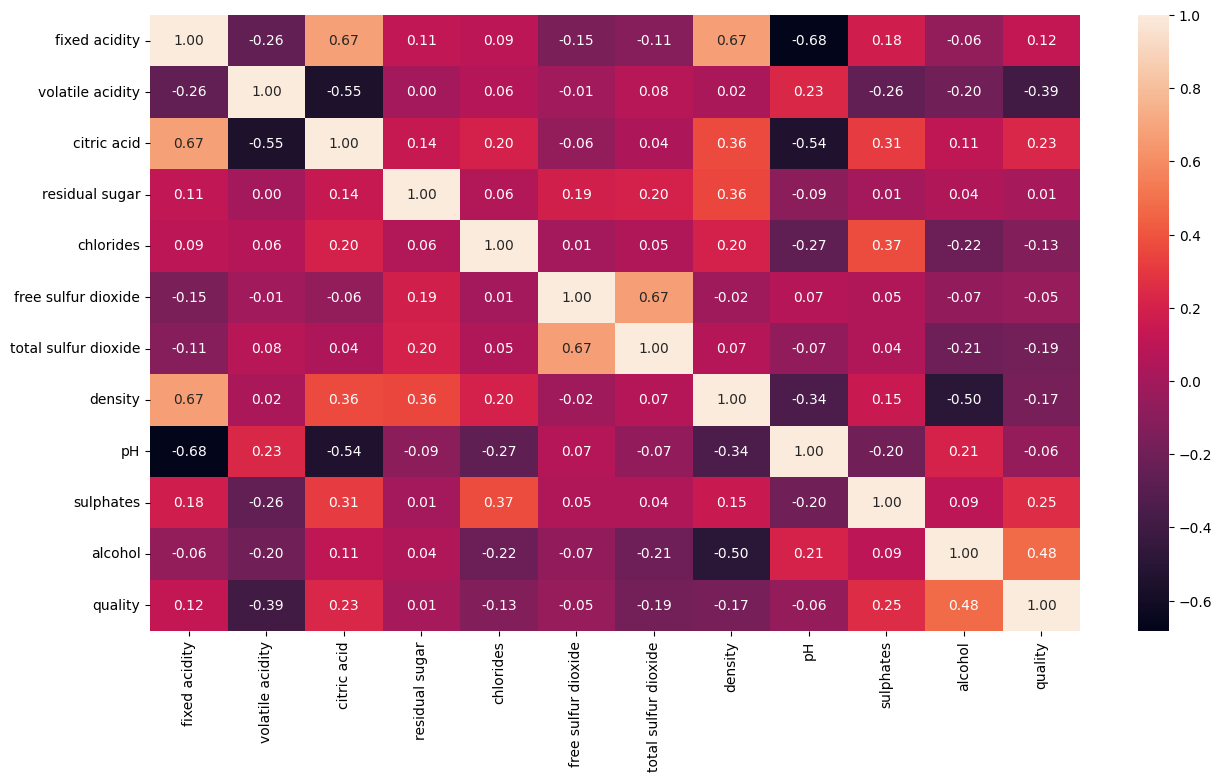

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,8))
sns.heatmap(df_wine.corr(), annot=True, fmt='.2f')

There are several features that are clearly correlated. We could use this information to simplify the dataset eliminating one of every pair of correlated variables, as they would provide roughly the same information to the machine learning model we will fit in the following chapters.

However, there is one moderate correlation (0.48) directly between one of the features (alcohol) and the target (quality) that we can investigate right now, without developing any model. Let's print a boxplot, in this case, using seaborn library:

In [ ]:
import plotly.express as px

px.box(data_frame = df_wine, x='quality', y='alcohol', points="all")

## **Define and traing a classification model**

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=0)

### **Define and fit a simple RandomForestClassifier model**

In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100, max_depth=8)
model.fit(X_train, y_train)


/usr/local/lib/python3.11/dist-packages/sklearn/base.py:1389: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().



RandomForestClassifier(max_depth=8)

Let's predict the quality for the whole dataset (instead of just the test dataset), because some classes (ie, 3 and 8) are under-represented:

In [ ]:
y_pred = model.predict(X_test)

y_pred_proba = model.predict_proba(X_test)

For example, this are the prediction probabilities for the first wine, X[0]:

In [ ]:
y_pred_proba[0]

array([3.95613023e-03, 3.20199391e-02, 8.20402288e-01, 1.33267341e-01,
       1.02981221e-02, 5.61797753e-05])

And this the final prediction, which in this case is true:

In [ ]:
#La predicción para el vino 0 es que es de la clase 5
y_pred[0]

5

Quality

3          Clase 0

4          Clase 1

5          Clase 2

6          Clase 3

7          Clase 4

8          Clase 5

In [ ]:
y_pred_df = pd.DataFrame(y_pred)

In [ ]:
y_pred_df.value_counts()

,count
0,
5,741
6,683
7,157
4,12
3,3
8,3


There are just a few wines classified as quality3, 4 or 8, as they are under-represented in the dataset. **This is a very bad classifier!!!!!!**

### **Using SHAP values to explain the model**

In [ ]:
!pip install shap

SHAP tiene varios explicadores:

Para modelos basados en árboles, usa `shap.TreeExplainer`. Hay otros explicadores para redes neuronales, métodos de kernel (como las SVM) y uno que es agnóstico al modelo.

In [ ]:
import shap

# for tree-based models, use TreeExplainer
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X)

In [ ]:
shap_values = explainer.shap_values(X)
print(type(shap_values))
print("shap_values.shape:", getattr(shap_values, 'shape', None))

<class 'numpy.ndarray'>
shap_values.shape: (1599, 11, 6)


### **Explaining a single prediction: force plots**

Let's try to explain why the model has predicted class5 for wine0 (X[0])

In [ ]:
#expected_value[2] -> La probabilidad media con la que han sido clasificados los vinos de array[2] clase 2 = vino de quality 5
#array[0] = calidad 3, array[1] = calidad 4, array[2] = calidad 5, array[3] = calidad 6, array[4] = calidad 7, array[5] = calidad 8
explainer.expected_value[2]

0.4270289288506646

0.4252384675527755 = 42%
Es el valor medio de confianza con el que los vinos de la clase 5 han sido clasificados con la clase 5

In [ ]:
shap_values_class2 = shap_values[:, :, 2] #(muestras, features, clases).
shap_values_class2

array([[ 0.01676896,  0.07967205,  0.00978164, ...,  0.02391699,
         0.05827744,  0.16852028],
       [ 0.01814676,  0.08154562,  0.00753757, ...,  0.01262561,
        -0.02010315,  0.17406241],
       [ 0.01304795,  0.07747239,  0.00614488, ...,  0.00235873,
        -0.02317781,  0.16163818],
       ...,
       [ 0.0134889 , -0.00763999,  0.01098841, ..., -0.00640709,
        -0.06915002, -0.17131917],
       [ 0.04934613,  0.06062171,  0.02424412, ...,  0.02491403,
        -0.03163246,  0.04368258],
       [ 0.02451708, -0.06618839, -0.0211339 , ..., -0.00133219,
        -0.01454904, -0.13516527]])

In [ ]:
# Obtenemos los shap values para la CLASE 2
shap_values_class2 = shap_values[:, :, 2]  # (1599, 11)

# Visualizamos la fila 0 (vino 0) para esa clase
shap.initjs()
shap.force_plot(
    explainer.expected_value[2],
    shap_values_class2[0],  # vector de 11 SHAP values
    X.iloc[0, :]            # 11 features
)

In [ ]:
#filas = cada una de las clases de los vinos
#columnas = vinos
#celda (shap value) = shap values de cada una de las caracteristicas para el vino 0, para que sea de la clase 2 (quality 5)
shap_values_class2[0]

array([ 0.01676896,  0.07967205,  0.00978164, -0.00030384,  0.01119228,
        0.00375841, -0.0199455 ,  0.04173464,  0.02391699,  0.05827744,
        0.16852028])

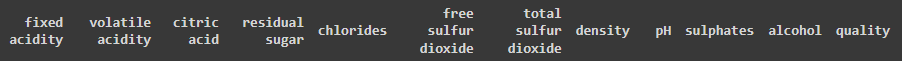

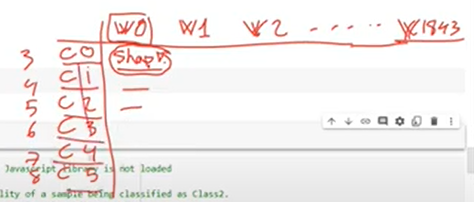

Los valores positivos contribuyen a que el vino 0 sea de la clase 2 (quality 5), los negativos constribuyen negativamente a que el vino sea de la clase 2 (quality 5).

Para visualizar mejor estos valores podemos usar la libreria de shap para representar gráficos de fuerza.

In [ ]:
shap.initjs() # following force_plot will not show if Javascript library is not loaded

# explainer.expected_value[2] is the expected probability of a sample being classified as Class2.
# that is, the mean of the predicted probabilities of samples classified as Class2.
# It is shown in the foce_plot as the 'base value'.
# shap_values[2][0] show which features are pushing to or against this base value.

#X.iloc[0, :] Todos los datos de la primera fila
shap_values_class3 = shap_values[:, :, 3]
shap.force_plot(explainer.expected_value[2], shap_values_class3[0], X.iloc[0, :])

El valor base: es el 42% (0,4252). Los vinos de la clase 2 o calidad 5, han sido clasificados de media como de esa clase con un 42% de confianza.

77%: Este vino pertenece a esta clase con un 77% de confianza, lo que quiere decir que estoy por encima del valor medio. Digo que ese vino es de la clase 2 con bastante credibilidad. Como el valor del 77% está por encima de la media lo clasifico con esa calidad.

Caracteristicas: las caracteristicas apoyan el 77% anterior tenemos:
- En rojo las caracteristicas que lo apoyan:
  + Que el alcohol sea de 9.4 actua en favor de que pertenezca a esta clase.
- En azul las que van en contra
  + Que el total sulfur dioxide = 34 va en contra. Los vinos de la clase 5 normalmente no tienen esa cantidad de dioxido de azufre.

Si wine0 (X[0]) pertenece a class5, entonces, shap_values[2][0] es muy positivo en este caso. El gráfico de fuerza muestra qué características están impulsando para aumentar la probabilidad de pertenecer a class5 y cuáles están luchando para disminuirla. La fuerza resultante empuja a pertenecer a Class2 con una probabilidad del 67%.

En contraste, shap_values[x][0] cuando x es diferente de 2, debería ser menor que el valor base, como se muestra a continuación para class3 (quality6) y class4 (quality7):

In [ ]:
shap.initjs() # following force_plot will not show if Javascript library is not loaded
shap.force_plot(explainer.expected_value[3], shap_values_class3[0], X.iloc[0, :])

0.3999 es el valor medio y para esta clase solo algunas caracteristicas harian que fuera de esa clase, pero para el vino 0, en su mayoria las caracteristicas pesan en su contra (13%), es decir, para que no sea de esa clase.


In [ ]:
shap.initjs() # following force_plot will not show if Javascript library is not loaded
shap_values_class4 = shap_values[:, :, 4]
shap.force_plot(explainer.expected_value[4], shap_values_class4[0], X.iloc[0, :])

En lugar de verlo vino a vino, podemos crear un gráfico de fuerzas para todos los vinos (desde el vino 0 hasta el 1400), los shapvalues como influyen para una de las clases.

- explainer.expected_value[2] =Para la clase 2 (calidad 5)
- shap_values[2][X] = para la clase 2 (calidad 5),
- X = todos los vinos, muestrame los shapvalues

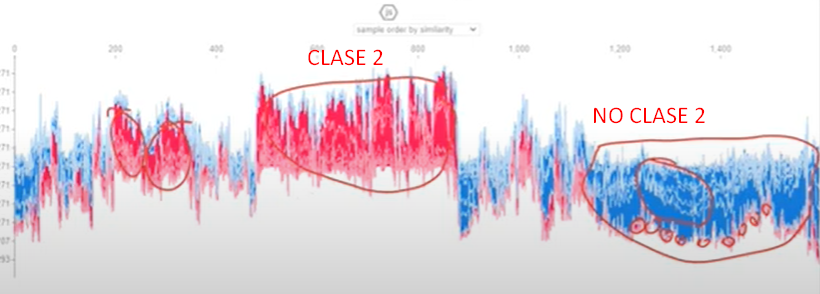

In [ ]:
shap.initjs() # following force_plot will not show if Javascript library is not loaded
shap.force_plot(explainer.expected_value[2], shap_values_class2, X)

### **Explaining a single feature: dependence plots**

Los **gráficos de dependencia** permiten explicar el efecto que **una característica** ('alcohol' en la figura de abajo) tiene sobre la salida del modelo, trazando los valores SHAP de esa característica versus el valor de la característica para todas las muestras en el conjunto de datos:

Ademas de explicar una unica predicción, podemos usar una unica feature aplicando gráficos de dependencia.

Me permiten explicar el efecto que una caracteristica, ej: la graduación alcoholica, tiene en la salida del modelo, plotando los valores de shap para esa caracteristica vs los valores de la caraceristica para todas las muestras en el dataset.

Le podemos decir a shap que haga un gráfico de dependencia, y le decimos que a la caracteristica alcohol, como influye el nivel alcoholico en la clase 2 (calida 5), **para todos los vinos** (X)

Esto es muy importante para poder usar modelos en la industria y evitar lo que se habla tanto de los sesgos, de las personas de raza negra, que el modelo no clasifica bien, que solo clasifica bien a las personas de piel blanca, etc. Esto nos explica muy bien por qué ha tomado esta decisión.

Funciona bien en datos tabulares.

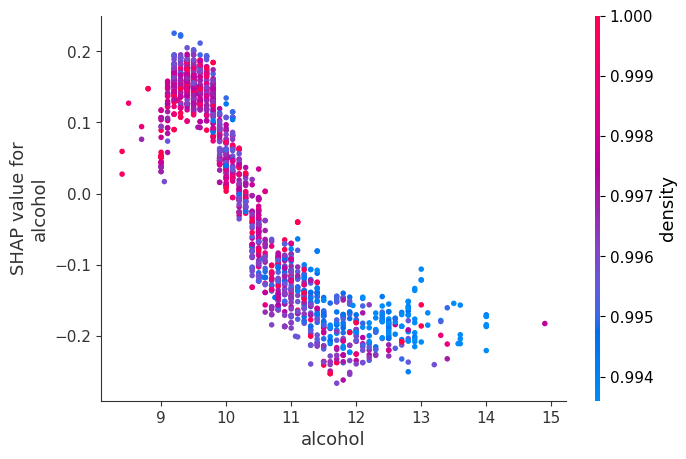

In [ ]:
# influence of the 'alcohol' feature on the wine class2 (quality5)
shap.dependence_plot('alcohol', shap_values_class2, X) # SHAP automatically selects another feature for coloring

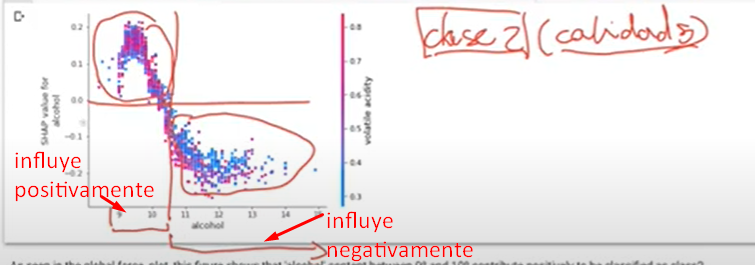

Los vinos con graduacion de 9 y 10 influye positivamente a que los vinos sean clasificados de esa clase 2 (calidad 5). Sin embargo los vinos con alcohol 11-14 influyen negativamente a que el vino sea clasificado de esa clase 2 (calidad 5).

As seen in the global force_plot, this figure shows that 'alcohol' content between 9º and 10º contribute positively to be classified as class2 (quality5). However, alcohol contents over 10.5º makes the wine not belonging to class2.

However, in the next figure it can be seen that, just the contrary is valid for classes 3 and 4, where values of alcohol under 10.5º are a sign of not belonging to those classes, whereas values over 10.5º contribute positively to both of them. This means that a higher level of alcohol is important for high quality wines (quality6 and 7):


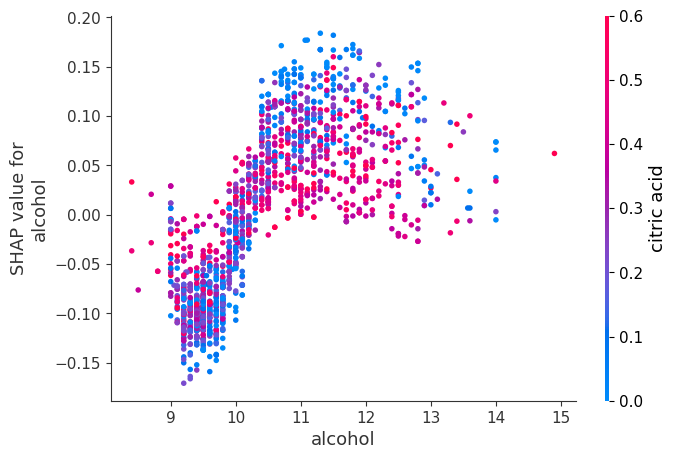

In [ ]:
# influence of the 'alcohol' feature on the wine class3 (quality6)
shap.dependence_plot('alcohol', shap_values_class3, X) # SHAP automatically selects another feature for coloring

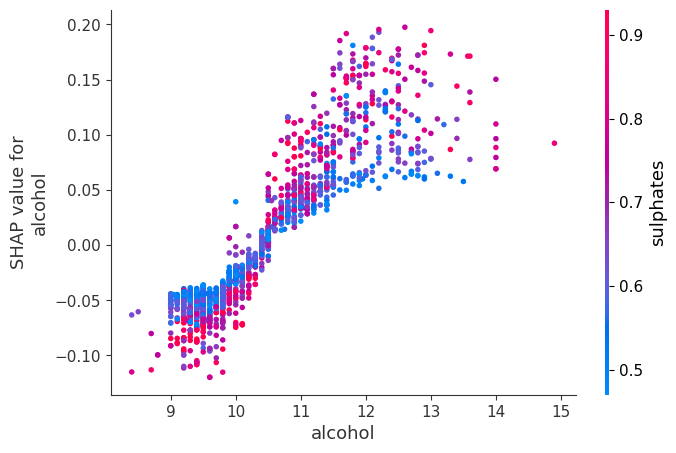

In [ ]:
# influence of the 'alcohol' feature on the wine class4 (quality7)

shap_values_class4 = shap_values[:, :, 4]

shap.dependence_plot('alcohol', shap_values_class4, X) # SHAP automatically selects another feature for coloring

### **Explaining the entire dataset: summary plots**

Summary plots visualize the importance of every feature on the prediction.

Con esto podemos conseguir algo parecido a lo que hacíamos con PCA. Tratar de quedarnos con las caracteristicas mas importantes.

En el grafico vemos que el alcohol es la caracteristica mas importante para algunas clases.

Pero para otras no, por ejemplo en la clase 5 no es tan importante.

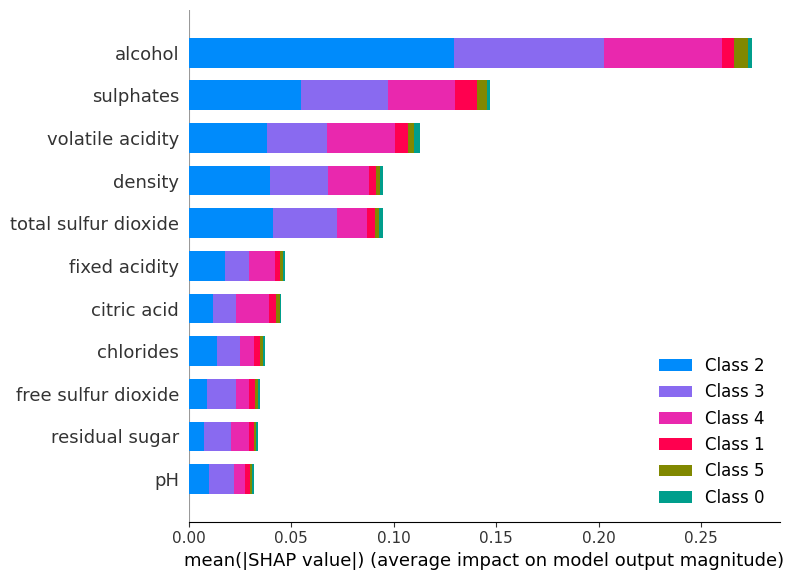

In [ ]:
#shap.summary_plot(shap_values, features=X) version antigua de shap 0.40

# 1) Convertimos el array 3D a una lista de 6 arrays 2D: uno para cada clase
shap_values_list = [shap_values[:, :, i] for i in range(shap_values.shape[2])]

# 2) Llamamos a summary_plot con la lista de arrays
# Esto suele reproducir el comportamiento "antiguo"
shap.summary_plot(
    shap_values_list,     # ahora es [ (1599,11), (1599,11), ..., (1599,11) ]
    features=X,           # tu DataFrame con 11 columnas
    plot_type="bar"       # si quieres el gráfico de barras
    # si quieres el gráfico tipo "dot", omite plot_type o pon plot_type="dot"
)

Se puede observar que el nivel de `alcohol` es la característica más importante para todas las clases, seguido por `sulphates` (sulfatos), `volatile acidity` (acidez volátil) y `total sulfur dioxide` (dióxido de azufre total). Sin embargo, para la Clase2, `total sulfur dioxide` es más diferenciador que `volatile acidity`.

# **Use `explainerdashboard` to explain the model**

Esto nos permite hacer lo mismo, pero en vez de con lineas de código de forma interactiva con un dashboard, a base de clicks.

### **Install Explainer DashBoard** (this is not requiered for just SHAP values)

From the authors (https://github.com/oegedijk/explainerdashboard):

This package makes it convenient to quickly deploy a dashboard web app that explains the workings of a (scikit-learn compatible) machine learning model.

In [ ]:
!pip install explainerdashboard

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 286.9/286.9 KB 5.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.0/47.0 KB 2.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.5/90.5 KB 6.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 60.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 60.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.7/57.7 KB 3.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 219.7/219.7 KB 9.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 575.9/575.9 KB 28.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 471.0/471.0 KB 25.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 KB 5.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 96.6/96.6 KB

In [ ]:
from explainerdashboard import ClassifierExplainer, ExplainerDashboard

In [ ]:
#explainer = ClassifierExplainer(model, X_test, y_test, labels=['Class0', 'Class1', 'Class2', 'Class3', 'Class4', 'Class5'])
#db = ExplainerDashboard(explainer, mode='inline').run(port=8051) # this will show an error because the dataset is unbalanced and some classes are not represented.

# **Another classification example**

### **Load dataset**

In [ ]:
from sklearn.datasets import load_wine

wine = load_wine()
X = wine.data
y = wine.target


In [ ]:
print(X.shape)
print(y.shape)

(178, 13)
(178,)


In [ ]:
print(wine.DESCR)

.. _wine_dataset:

Wine recognition dataset
------------------------

**Data Set Characteristics:**

:Number of Instances: 178
:Number of Attributes: 13 numeric, predictive attributes and the class
:Attribute Information:
    - Alcohol
    - Malic acid
    - Ash
    - Alcalinity of ash
    - Magnesium
    - Total phenols
    - Flavanoids
    - Nonflavanoid phenols
    - Proanthocyanins
    - Color intensity
    - Hue
    - OD280/OD315 of diluted wines
    - Proline
    - class:
        - class_0
        - class_1
        - class_2

:Summary Statistics:

============================= ==== ===== ======= =====
                                Min   Max   Mean     SD
============================= ==== ===== ======= =====
Alcohol:                      11.0  14.8    13.0   0.8
Malic Acid:                   0.74  5.80    2.34  1.12
Ash:                          1.36  3.23    2.36  0.27
Alcalinity of Ash:            10.6  30.0    19.5   3.3
Magnesium:                    70.0 162.0    99.7  14.3

### **Preprocess dataset**

In [ ]:
import pandas as pd

X_df = pd.DataFrame(X, columns=['Alcohol', 'Malic_acid', 'Ash', 'Alcalinity_ash', 'Magnesium', 'Phenols',
                                'Flavanoids', 'Nonflavanoid_phenols', 'Proanthocyanins', 'Color', 'Hue', 'OD280_OD315', 'Proline'])
X_df.head()

,Alcohol,Malic_acid,Ash,Alcalinity_ash,Magnesium,Phenols,Flavanoids,Nonflavanoid_phenols,Proanthocyanins,Color,Hue,OD280_OD315,Proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


In [ ]:
y_ser = pd.DataFrame(y)
y_ser.head()

,0
0,0
1,0
2,0
3,0
4,0


In [ ]:
y_ser.value_counts() # this is a balanced dataset, we should have no problem with ExplainerDashboard

,count
0,
1,71
0,59
2,48


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_df, y_ser, test_size=0.2, random_state=0)

### **Define and fit a simple RandomForestClassifier model**

In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=50, max_depth=5)
model.fit(X_train, y_train)


/usr/local/lib/python3.11/dist-packages/sklearn/base.py:1389: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().



RandomForestClassifier(max_depth=5, n_estimators=50)

# **Using `shap` values to explain the model**

The SHAP values provide two levels of interpretability:

1. Global interpretability: the collective SHAP values show how much (positively or negatively) each feature contributes to the target variable.

2. Local interpretability: individual SHAP values for a given data sample can explain why that sample has got a given prediction, and the contribution of each feature in the obtained prediction.

In [ ]:
# NOTE: if explainer_dashboard has not been installed, shap library needs to be installed independently:
# !pip install shap
import shap

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_df)

In [ ]:
shap_values

array([[[ 6.84895255e-02, -7.24827980e-02,  3.99327250e-03],
        [ 2.87990376e-03,  6.21539416e-03, -9.09529792e-03],
        [ 1.94998342e-03, -2.35224773e-03,  4.02264310e-04],
        ...,
        [ 1.35546860e-02,  1.04854533e-02, -2.40401393e-02],
        [ 9.14439145e-02, -1.16966236e-02, -7.97472909e-02],
        [ 2.09749338e-01, -1.44895887e-01, -6.48534509e-02]],

       [[ 5.64924036e-02, -6.69873638e-02,  1.04949602e-02],
        [ 5.72770877e-03,  5.77701599e-03, -1.15047248e-02],
        [-1.58948278e-03,  2.34026696e-03, -7.50784173e-04],
        ...,
        [ 1.20630565e-02,  1.19705946e-02, -2.40336511e-02],
        [ 9.22116466e-02, -7.06780980e-03, -8.51438368e-02],
        [ 2.16083050e-01, -1.70137995e-01, -4.59450548e-02]],

       [[ 5.64309727e-02, -6.05492740e-02,  4.11830135e-03],
        [-6.04066104e-03, -1.26754680e-03,  7.30820784e-03],
        [ 4.68206343e-03, -6.55631976e-03,  1.87425632e-03],
        ...,
        [ 1.28748263e-02,  8.46434193e-03,

In [ ]:
shap_values_class0 = shap_values[:, :, 2]
shap_values_class0[0]

array([ 0.00399327, -0.0090953 ,  0.00040226, -0.01212474, -0.00234624,
       -0.02321352, -0.10447822, -0.01655834, -0.01331853,  0.04847882,
       -0.02404014, -0.07974729, -0.06485345])

Partial dependence plots show the influence of a given feature in the target variable:

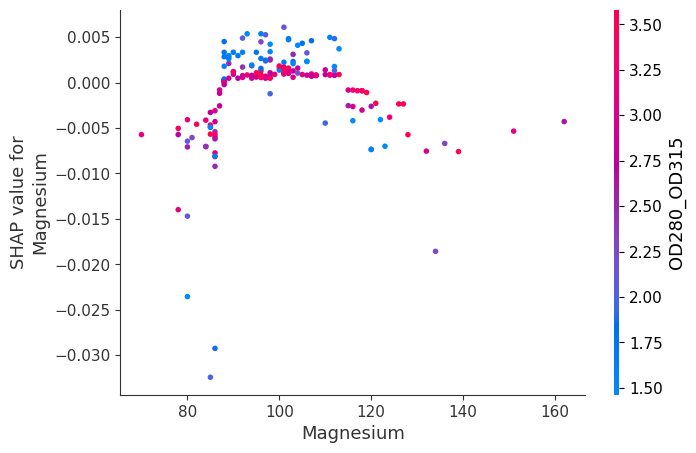

In [ ]:
# Partial Dependence plot: influence of the 4th feature (Magnesium) on the first class (0)
shap.dependence_plot('Magnesium', shap_values_class0, X_df) # SHAP automatically selects another feature for coloring

From the figure, it is clear than high values of Magnesium are relevant to be classified as Class0.

However, lower levels of Magnesium contribute positively to be classified as Class1, see next figure:

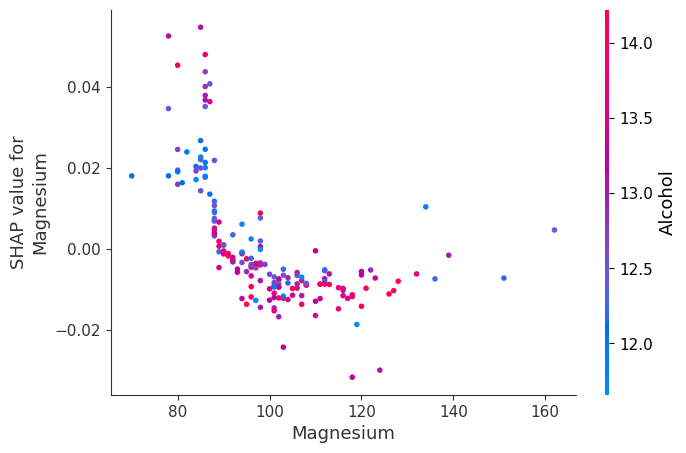

In [ ]:
shap_values_class1 = shap_values[:, :, 1]

shap.dependence_plot('Magnesium', shap_values_class1, X_df) # SHAP automatically selects another feature for coloring

Global interpretability: importance of each feature for each class. This is different of Feature Importance plots in that here the importance of a feature is determined for each class, not globally.

When in a binary classification problem, the summaty_plot shows if the contribution to the target variable is positive or negative.

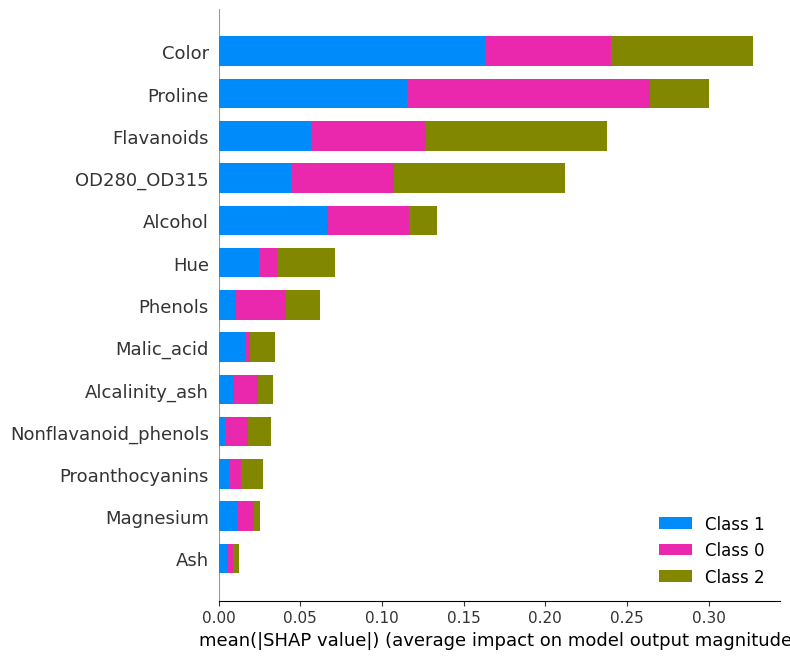

In [ ]:
# 1) Convertimos el array 3D a una lista de 6 arrays 2D: uno para cada clase
shap_values_list = [shap_values[:, :, i] for i in range(shap_values.shape[2])]

# 2) Llamamos a summary_plot con la lista de arrays
# Esto suele reproducir el comportamiento "antiguo"
shap.summary_plot(
    shap_values_list,     # ahora es [ (1599,11), (1599,11), ..., (1599,11) ]
    features=X_df,           # tu DataFrame con 11 columnas
    plot_type="bar"       # si quieres el gráfico de barras
    # si quieres el gráfico tipo "dot", omite plot_type o pon plot_type="dot"
)

Color intensity is the most determinant feature in average, followed by Flavanoids, Proline and OD280_OD315, with roughgly the same importance. However, in case of Class0, Proline is more important than Color of Flavanoids.

# **Use `explainerdashboard` to explain the model**

In [ ]:
from explainerdashboard import ClassifierExplainer, ExplainerDashboard

In [ ]:
# explainer = ClassifierExplainer(model, X_test, y_test,
  # cats=['Alcohol', 'Malic_acid', 'Ash', 'Alcalinity_of_ash', 'Magnesium',
	# 	    'Total_phenols', 'Flavanoids', 'Nonflavanoid_phenols', 'Proanthocyanins',
  #       'Color_intensity', 'Hue', 'OD280_OD315', 'Proline'],
  # descriptions=feature_descriptions, # defaults to None
  # labels=['class0', 'class1', 'class2'], # defaults to ['0', '1', etc]
  # idxs = test_names, # defaults to X.index
  # index_name = "Passenger", # defaults to X.index.name
  # target = "Survival", # defaults to y.name
# )

# db = ExplainerDashboard(explainer,
#   mode='inline',  # to display DashBoard in the jupyter notebook
#   title="Wine Explainer", # defaults to "Model Explainer"
#   whatif=False, # you can switch off tabs with bools
#                         )
# db.run(port=8050)

# concise single-line command:
explainer = ClassifierExplainer(model, X_test, y_test, labels=['Class0', 'Class1', 'Class2'])
db = ExplainerDashboard(explainer, mode='inline').run(port=8051)


Detected RandomForestClassifier model: Changing class type to RandomForestClassifierExplainer...
Note: model_output=='probability', so assuming that raw shap output of RandomForestClassifier is in probability space...
Generating self.shap_explainer = shap.TreeExplainer(model)
Building ExplainerDashboard..
Generating layout...
Calculating shap values...
Calculating prediction probabilities...
Calculating metrics...
Calculating confusion matrices...
Calculating classification_dfs...
Calculating roc auc curves...
Calculating pr auc curves...
Calculating liftcurve_dfs...
Calculating shap interaction values... (this may take a while)
Reminder: TreeShap computational complexity is O(TLD^2), where T is the number of trees, L is the maximum number of leaves in any tree and D the maximal depth of any tree. So reducing these will speed up the calculation.
Calculating dependencies...
Calculating permutation importances (if slow, try setting n_jobs parameter)...
Calculating pred_percentiles...
Cal

<IPython.core.display.Javascript object>

**Feature Importances**

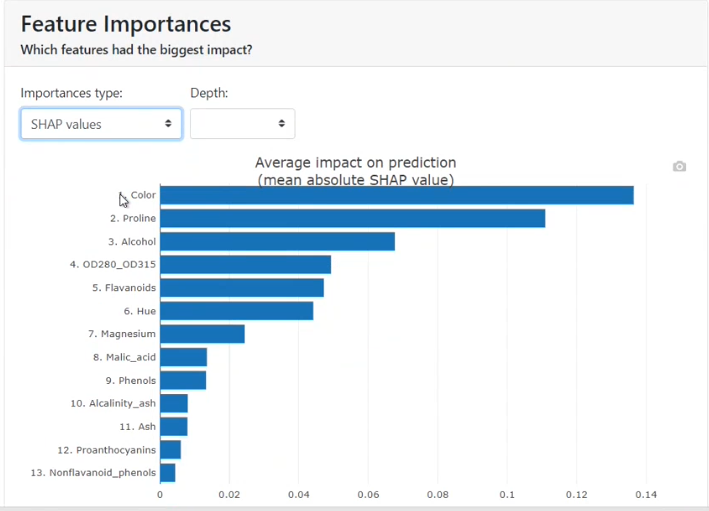

**Clasification Stats**

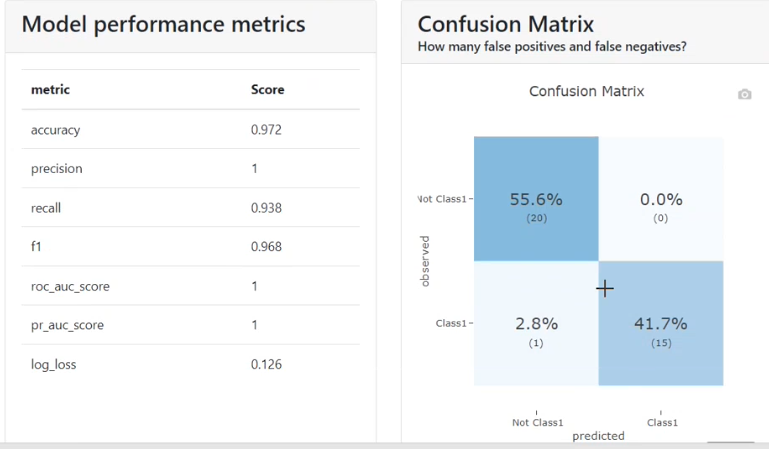

**Individual Predictions**

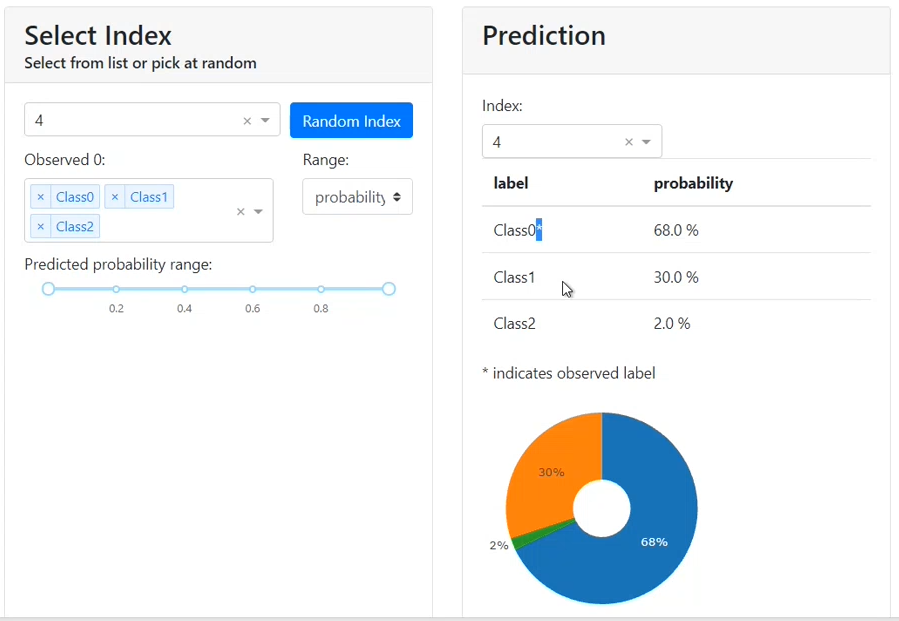

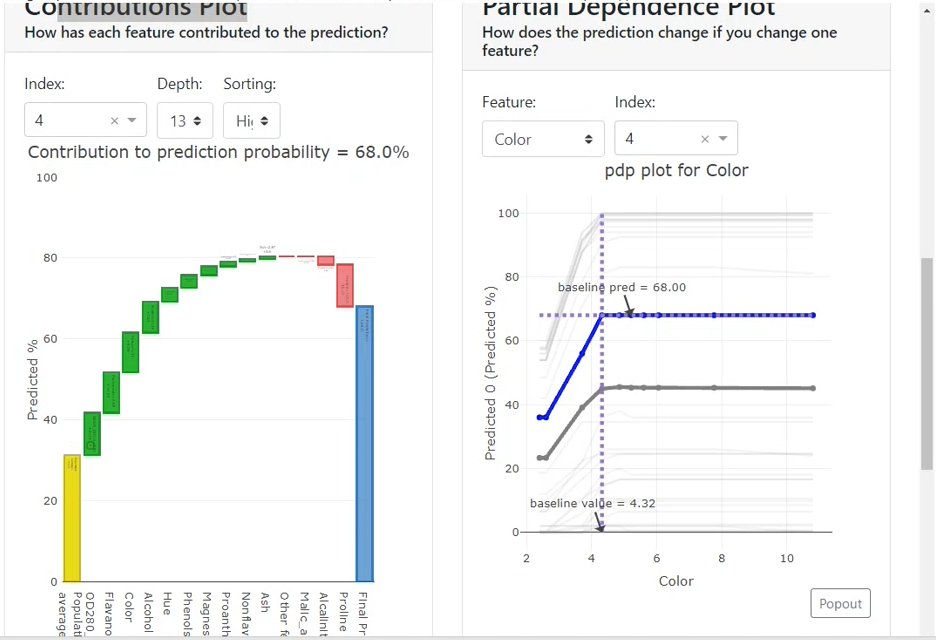

**Feature Dependences**

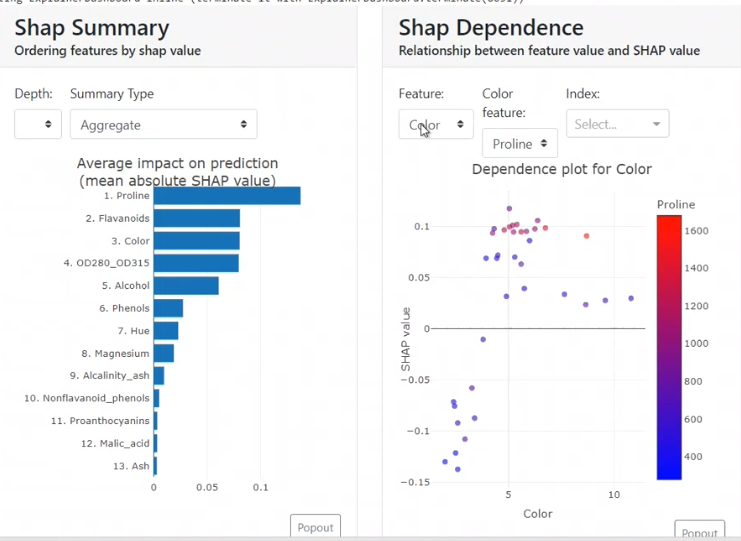